<a href="https://colab.research.google.com/github/VincenzoDamico/ProteinDynamics/blob/LSTM/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
pip install tensorflow #You only need it if you’re using the TPU 5 at runtime, which is a processor dedicated to training machine learning algorithms.


# Library setting



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from sklearn.preprocessing import StandardScaler
import os
import random
import keras


Seeting the seeds:

In [ ]:
# fix random seed for reproducibility
def set_all_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_all_seeds(42)
np.random.seed(42) #it also fix the seed for sklearn

# Inizialization of Input Data

In [ ]:
driver_path='/content/drive/MyDrive/ProteinDynamics/'

In [ ]:
coordinates_df = pd.read_csv(driver_path+'coordinates.csv', header=None, index_col=False, sep=';')
# header= none: we don't have col names in the first raw
# index_col: we don't have a col for the index
print(coordinates_df.head(), coordinates_df.shape)

# Forces:
forces_df_raw = pd.read_csv(driver_path+'forces.csv', header=None, index_col=False, sep=None, engine='python')
# sep = none means pandas will search to find the separator
forces_df = forces_df_raw[0].str.split('\t', expand=True)
forces_df = forces_df.apply(pd.to_numeric, errors='coerce')
print(forces_df.head(), forces_df.shape)

# velocity:
velocities_df_raw = pd.read_csv(driver_path+'velocity.csv', header=None, index_col=False, sep=None, engine='python')
velocities_df = velocities_df_raw[0].str.split('\t', expand=True)
velocities_df = velocities_df.apply(pd.to_numeric, errors='coerce')
print(velocities_df.head(), velocities_df.shape)

     0        1        2        3        4        5        6        7    \
0  0.000  56.3980  51.9370  52.6880  56.3750  52.0050  52.6170  56.4260   
1  0.002  56.3992  51.9368  52.6877  56.3743  52.0037  52.6162  56.4267   
2  0.004  56.3999  51.9366  52.6871  56.3767  52.0046  52.6161  56.4285   
3  0.006  56.4001  51.9364  52.6861  56.3816  52.0073  52.6167  56.4315   
4  0.008  56.4001  51.9362  52.6848  56.3876  52.0109  52.6179  56.4350   

       8        9    ...      405      406      407      408      409  \
0  51.8530  52.6400  ...  52.1880  56.7460  52.0040  52.3850  56.7650   
1  51.8556  52.6344  ...  52.1872  56.7448  52.0025  52.3849  56.7651   
2  51.8579  52.6307  ...  52.1890  56.7434  52.0011  52.3842  56.7652   
3  51.8594  52.6288  ...  52.1930  56.7417  52.0001  52.3832  56.7652   
4  51.8597  52.6288  ...  52.1982  56.7402  51.9995  52.3824  56.7651   

       410      411      412      413      414  
0  51.9040  52.4540  56.7550  52.1200  52.4210  
1  51.9044  


LSTMs are sensitive to the scale of the input data, specifically when the sigmoid (default) or tanh activation functions are used. It can be a good practice to rescale the data to the range of 0-to-1



In [ ]:
NUM_ATOMS = 138
feaature_xyz=3
n_db=3 #consider 3 datebase with the same feature
num_features = NUM_ATOMS * feaature_xyz*n_db

In [ ]:
coords = coordinates_df.iloc[:, 1:].values
vels   = velocities_df.iloc[:, 1:].values
forces = forces_df.iloc[:, 1:].values

coords = coords.reshape(-1,NUM_ATOMS, feaature_xyz)
vels   = vels.reshape(-1, NUM_ATOMS, feaature_xyz)
forces = forces.reshape(-1, NUM_ATOMS, feaature_xyz)

#3- Concatenate Features to be [x,y,z,vx,vy,vz,fx,fy,fz]
features = np.concatenate(
    [coords, vels, forces],
    axis=-1
)

In [ ]:
N= len(features)                # 50001
train_end = int(N * 0.70)   # 35000
val_end = int(N * 0.85)         # 42500

In [ ]:
features_flattened = features.reshape(N, num_features)


In [ ]:
features_flattened

array([[   56.398 ,    51.937 ,    52.688 , ...,   118.451 ,  1627.09  ,
          847.998 ],
       [   56.3992,    51.9368,    52.6877, ...,    14.3658,  1262.76  ,
          625.43  ],
       [   56.3999,    51.9366,    52.6871, ...,  -149.193 ,   670.503 ,
          258.009 ],
       ...,
       [   21.3855,    21.1404,    21.1561, ...,   -12.7531,  -878.779 ,
          289.71  ],
       [   21.3849,    21.1387,    21.1554, ...,  -239.713 , -1253.8   ,
          142.908 ],
       [   21.3843,    21.1372,    21.1545, ...,   -70.7549, -1215.85  ,
          177.951 ]])

In [ ]:
features_flattened = features.reshape(N, num_features)
scaler = StandardScaler()
scaler.fit(features_flattened[:train_end])
features_scaled = scaler.transform(features_flattened)

In [ ]:
features_scaled[0][3]

np.float64(1.8112944879624555)

In [ ]:
print(features_scaled.shape)

(50001, 1242)


# Prediction Sequence Model

In this case we are trying to develop a sequence model that is able given as input a window of 4 previous coordinates, velocity and force to predit the next one. The model that ee designed take as input all the data and give as the result the prediction in addtion in designed to implement a supervised learning.



In [ ]:
look_back=4
epochs= 64
batchs_size=32

Adjust the input data to match the LMTS Model standard. The LSTM network expects the input data (X) to be provided with a specific array structure in the form of [samples, time steps, features].


we also shift the dateset to let the model be able to try to predict also withut all the previous step

In [ ]:
nb_samples = len(features_scaled)

pad_rows = np.zeros((look_back, num_features))
features_padded = np.vstack((pad_rows, features_scaled))

X_reshaped = np.zeros((nb_samples, look_back, num_features))
Y_reshaped = np.zeros((nb_samples ,num_features))

for i in np.arange(0,nb_samples):
    X_reshaped[i] = features_padded[i:i+look_back].reshape(look_back, num_features)
    Y_reshaped[i] = features_scaled[i]



Use MAE to track the average error instead of accuracy because I’m making a prediction, and accuracy is a metric used for classification.

In [ ]:

trainX=X_reshaped[:train_end]
testX=X_reshaped[train_end:val_end]
valX=X_reshaped[val_end:]

trainY=Y_reshaped[:train_end]
testY=Y_reshaped[train_end:val_end]
valY=Y_reshaped[val_end:]

model = tf.keras.Sequential([

    # Bidirectional LSTM to capture patterns in both directions of the sequence
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=False, dropout=0.1)),
    tf.keras.layers.Dense(256, activation='relu'),
    # Final layer matches the 1242 features we want to predict
    # Default activation is 'linear', which is perfectly correct for regression
    tf.keras.layers.Dense(num_features)
])

# Compile using Mean Squared Error
model.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    metrics=[tf.keras.metrics.MeanAbsoluteError()] # Use MAE to track average error
)

# Train the model
history = model.fit(
    x=trainX, y=trainY,
    epochs=epochs,
    batch_size=batchs_size, # Batch size helps memory management and gradient calculation
    validation_data=(valX, valY)
)
trainPredict = model.predict(trainX)
# make predictions


Epoch 1/64
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 0.6812 - mean_absolute_error: 0.5654 - val_loss: 2.0126 - val_mean_absolute_error: 1.1749
Epoch 2/64
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.6383 - mean_absolute_error: 0.5378 - val_loss: 1.8023 - val_mean_absolute_error: 1.1150
Epoch 3/64
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.6057 - mean_absolute_error: 0.5227 - val_loss: 1.7006 - val_mean_absolute_error: 1.0837
Epoch 4/64
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.5761 - mean_absolute_error: 0.5082 - val_loss: 1.5703 - val_mean_absolute_error: 1.0398
Epoch 5/64
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - loss: 0.5514 - mean_absolute_error: 0.4958 - val_loss: 1.5212 - val_mean_absolute_error: 1.0221
Epoch 6/64
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 0.5297 - mean_absolute_error: 0.4851 - val_loss: 1.4944 - val_mean_absolute_error: 1.0125
Epoch 7/64
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.5072 - mean_a

Save the model or load it from the drive

In [ ]:
driver_path='/content/drive/MyDrive/ProteinDynamics/'

In [ ]:
model.save(driver_path+'model_dense.keras')

In [ ]:
model = keras.models.load_model(driver_path+'model_dense.keras')


In [ ]:
test_loss, test_acc = model.evaluate(testX,testY)

print('Test Loss:', test_loss)
print('Test MeanAbsoluteError:', test_acc)

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5290 - mean_absolute_error: 0.4886
Test Loss: 0.529015064239502
Test MeanAbsoluteError: 0.4885540306568146


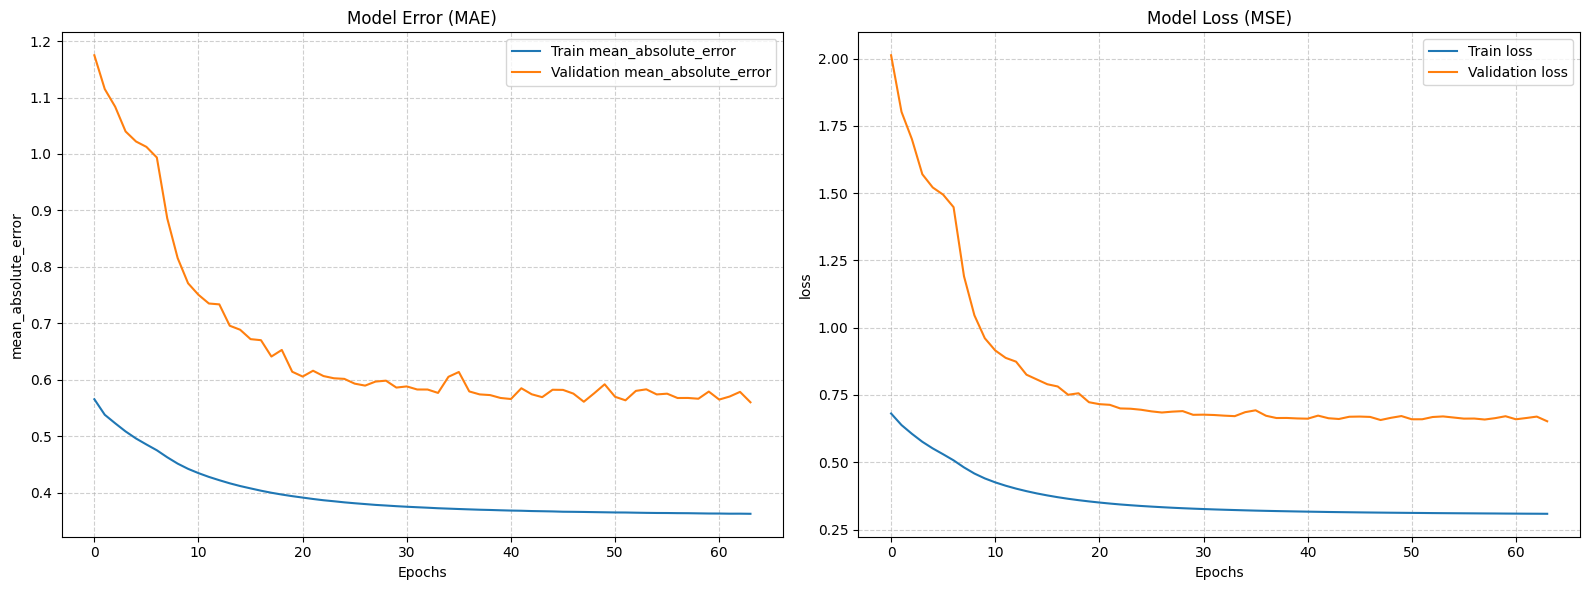

In [ ]:

def plot_graphs(history, metric, title):
    # Pass labels directly to the plot function for a cleaner legend
    plt.plot(history.history[metric], label=f'Train {metric}')
    plt.plot(history.history['val_' + metric], label=f'Validation {metric}')
    plt.xlabel("Epochs")
    plt.ylabel(metric)
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6) # Adding a grid helps read continuous metrics

plt.figure(figsize=(16, 6))

# Subplot 1: Mean Absolute Error (Replaces Accuracy)
plt.subplot(1, 2, 1)
# Keras usually tracks MAE as 'mean_absolute_error' or 'mae' depending on the exact string used
metric_name = 'mean_absolute_error' if 'mean_absolute_error' in history.history else 'mae'
plot_graphs(history, metric_name, 'Model Error (MAE)')

# Subplot 2: Loss (Mean Squared Error)
plt.subplot(1, 2, 2)
plot_graphs(history, 'loss', 'Model Loss (MSE)')

# Optional: If your initial error is incredibly high and drops fast,
# the graph will look like an "L" shape. Uncommenting the line below
# puts the Y-axis on a log scale so you can see the fine details of the training curve.
# plt.yscale('log')

plt.tight_layout()
plt.savefig('training_curves.png') # Good practice to save the plot!
plt.show()

In [ ]:
predictions= model.predict(testX)
predictions=scaler.inverse_transform(predictions)
testY_v=scaler.inverse_transform(testY)

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


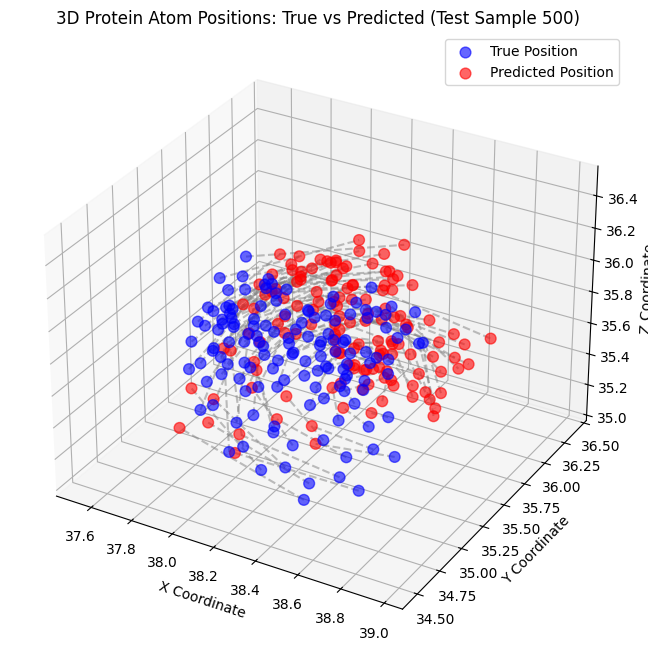

In [ ]:
preds_reshaped = predictions.reshape(-1, NUM_ATOMS, 9)
true_reshaped = testY_v.reshape(-1, NUM_ATOMS, 9)

# 2. Pick a single prediction step to look at (e.g., the very first test sample)
sample_idx = 500

# 3. Slice out ONLY the first 3 columns (X, Y, Z) for all 138 atoms
preds_xyz = preds_reshaped[sample_idx, :, 0:3]
true_xyz = true_reshaped[sample_idx, :, 0:3]

# 4. Set up the 3D Matplotlib figure
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the True positions in Blue
ax.scatter(true_xyz[:, 0], true_xyz[:, 1], true_xyz[:, 2],
           c='blue', label='True Position', alpha=0.6, s=60)

# Plot the Predicted positions in Red
ax.scatter(preds_xyz[:, 0], preds_xyz[:, 1], preds_xyz[:, 2],
           c='red', label='Predicted Position', alpha=0.6, s=60)

# 5. Draw a line connecting the True atom to the Predicted atom to visualize the error
for i in range(NUM_ATOMS):
    ax.plot([true_xyz[i, 0], preds_xyz[i, 0]],
            [true_xyz[i, 1], preds_xyz[i, 1]],
            [true_xyz[i, 2], preds_xyz[i, 2]],
            color='gray', linestyle='--', alpha=0.5)

# Labels and Title
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Coordinate')
ax.set_title(f'3D Protein Atom Positions: True vs Predicted (Test Sample {sample_idx})')
plt.legend()
plt.show()



I also tried implementing a larger model with an LSTM layer of 256 units followed by a Dense layer of 512 units, moving the dropout from the LSTM to the Dense layer while keeping the same value (0.1). However, this change caused the model to overfit even more. Simply increasing the model size did not help either: the training loss improved slightly (down to 0.286), but the validation loss increased to 0.356.
Increasing the number of epochs also did not provide any benefit.
Also, taking into consideration a dropout layer and/or just increasing the dropout value doesn’t help because the model is not able to learn and it's stops around a validation loss of 0.6 .
Given these results, I decided to explore different model architectures to see whether they could achieve better performance, since this configuration is the best result I have obtained so far.

Some of the experiments I ran are saved on GitHub.

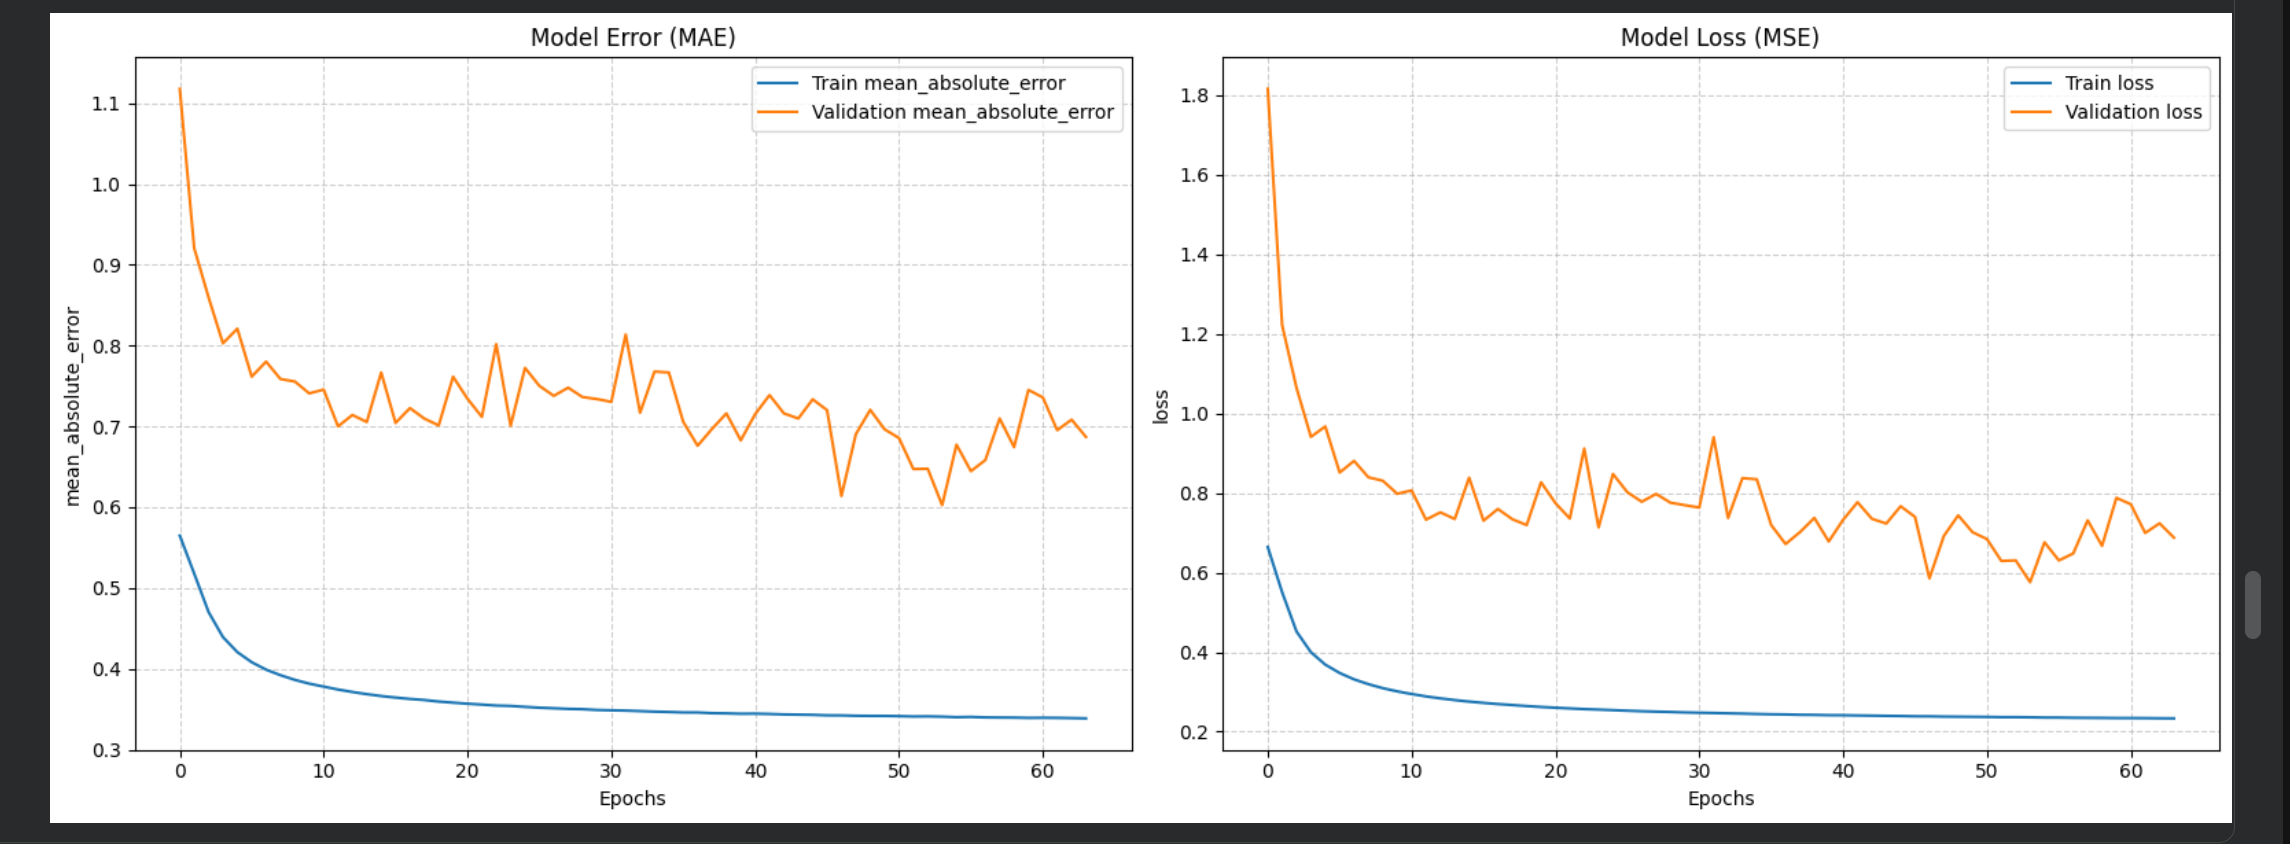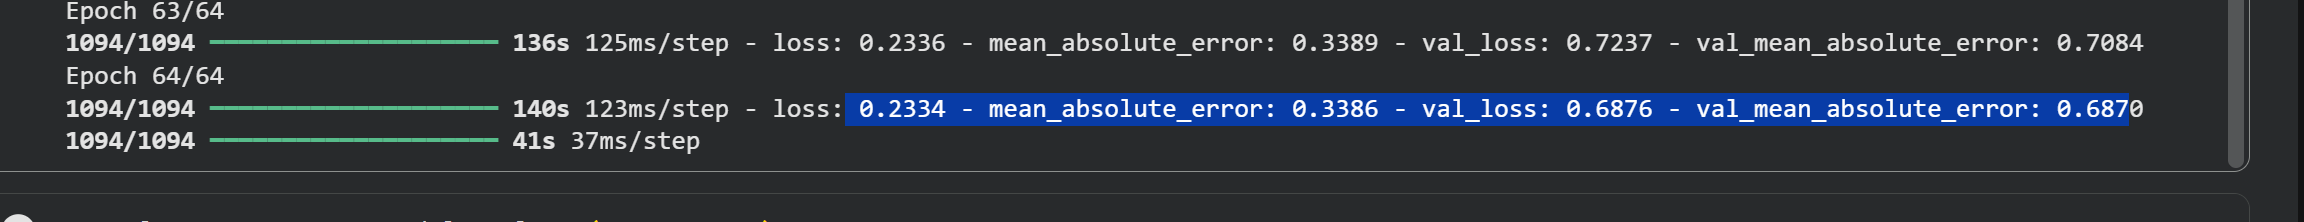

print and save of the data

In [ ]:
import numpy as np
from google.colab import files

# Slice out ONLY the first 3 columns (X, Y, Z) for all timestamps and atoms
preds_xyz_all = preds_reshaped[:, :, 0:3]
true_xyz_all = true_reshaped[:, :, 0:3]

# Save the sliced arrays to a compressed file
filename = 'protein_dynamics_data.npz'
np.savez_compressed(
    filename,
    preds=preds_xyz_all,
    true_vals=true_xyz_all
)

print(f"Data saved to {filename}. Downloading...")

# Trigger the download to your local machine
files.download(filename)

Data saved to protein_dynamics_data.npz. Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Predict using a multiinput multinput model


In [ ]:
look_back=4
epochs= 30
batchs_size=32

In [ ]:
nb_samples = len(features_scaled)

pad_rows = np.zeros((look_back, num_features))
features_padded = np.vstack((pad_rows, features_scaled))

X_reshaped = np.zeros((nb_samples, look_back, num_features))
Y_reshaped = np.zeros((nb_samples ,num_features))

for i in np.arange(0,nb_samples):
    X_reshaped[i] = features_padded[i:i+look_back].reshape(look_back, num_features)
    Y_reshaped[i] = features_scaled[i]



In [ ]:
trainX_coord=X_reshaped[:train_end,:,0:138*3]
testX_coord=X_reshaped[train_end:val_end,:,0:138*3]
valX_coord=X_reshaped[val_end:,:,0:138*3]

trainY_coord=Y_reshaped[:train_end,0:138*3]
testY_coord=Y_reshaped[train_end:val_end,0:138*3]
valY_coord=Y_reshaped[val_end:,0:138*3]

In [ ]:
trainX_vels=X_reshaped[:train_end,:,138*3:138*6]
testX_vels=X_reshaped[train_end:val_end,:,138*3:138*6]
valX_vels=X_reshaped[val_end:,:,138*3:138*6]

trainY_vels=Y_reshaped[:train_end,138*3:138*6]
testY_vels=Y_reshaped[train_end:val_end,138*3:138*6]
valY_vels=Y_reshaped[val_end:,138*3:138*6]

In [ ]:
trainX_forces=X_reshaped[:train_end,:,138*6:]
testX_forces=X_reshaped[train_end:val_end,:,138*6:]
valX_forces=X_reshaped[val_end:,:,138*6:]

trainY_forces=Y_reshaped[:train_end,138*6:]
testY_forces=Y_reshaped[train_end:val_end,138*6:]
valY_forces=Y_reshaped[val_end:,138*6:]

In [ ]:
input_coord = tf.keras.layers.Input(shape=(look_back, 138*3), name='in_coord')
input_vels = tf.keras.layers.Input(shape=(look_back, 138*3), name='in_vels')
input_forces = tf.keras.layers.Input(shape=(look_back, 138*3), name='in_forces')

# 1. Non sovrascrivere input_vels, usa un nome nuovo
combined_all = tf.keras.layers.concatenate([input_coord, input_vels, input_forces])

d = tf.keras.layers.Dense(128, activation='relu')(combined_all)
drop = tf.keras.layers.Dropout(0.1)(d)

relation = tf.keras.layers.Dense(256, activation='relu')(drop)

# 2. Concatenazione dei rami specifici
relation_c = tf.keras.layers.concatenate([input_coord, relation])
relation_v = tf.keras.layers.concatenate([input_vels, relation])
relation_f = tf.keras.layers.concatenate([input_forces, relation])

cLSTM = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=False, dropout=0.1))(relation_c)
vLSTM = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=False, dropout=0.1))(relation_v)
fLSTM = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=False, dropout=0.1))(relation_f)

output_c = tf.keras.layers.Dense(NUM_ATOMS * feaature_xyz, name='out_coord')(cLSTM)
output_v = tf.keras.layers.Dense(NUM_ATOMS * feaature_xyz, name='out_vels')(vLSTM)
output_f = tf.keras.layers.Dense(NUM_ATOMS * feaature_xyz, name='out_forces')(fLSTM)

# 3. Ora gli 'inputs' puntano correttamente ai layer Input originali
model = tf.keras.Model(inputs=[input_coord, input_vels, input_forces], outputs=[output_c, output_v, output_f])

# Compile
model.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    metrics=[tf.keras.metrics.MeanAbsoluteError(), tf.keras.metrics.MeanAbsoluteError(), tf.keras.metrics.MeanAbsoluteError()] # Use MAE to track average error for each output
)

model.summary()

# Train
history = model.fit(
    x=[trainX_coord, trainX_vels, trainX_forces],
    y=[trainY_coord, trainY_vels, trainY_forces],
    epochs=epochs,
    batch_size=batchs_size,
    validation_data=([valX_coord, valX_vels, valX_forces], [valY_coord, valY_vels, valY_forces])
)

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ in_coord            │ (None, 4, 414)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_vels             │ (None, 4, 414)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_forces           │ (None, 4, 414)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 4, 1242)   │          0 │ in_coord[0][0],   │
│ (Concatenate)       │                   │            │ in_vels[0][0],    │
│                     │                   │            │ in_forces[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 4, 128)    │    159,104 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 4, 128)    │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 4, 256)    │     33,024 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 4, 670)    │          0 │ in_coord[0][0],   │
│ (Concatenate)       │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 4, 670)    │          0 │ in_vels[0][0],    │
│ (Concatenate)       │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 4, 670)    │          0 │ in_forces[0][0],  │
│ (Concatenate)       │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 256)       │    818,176 │ concatenate_5[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_5     │ (None, 256)       │    818,176 │ concatenate_6[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_6     │ (None, 256)       │    818,176 │ concatenate_7[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out_coord (Dense)   │ (None, 414)       │    106,398 │ bidirectional_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out_vels (Dense)    │ (None, 414)       │    106,398 │ bidirectional_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out_forces (Dense)  │ (None, 414)       │    106,398 │ bidirectional_6[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,965,850 (11.31 MB)

 Trainable params: 2,965,850 (11.31 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 33s 23ms/step - loss: 1.8957 - out_coord_loss: 0.6366 - out_coord_mean_absolute_error: 0.5671 - out_forces_loss: 0.6329 - out_forces_mean_absolute_error: 0.5652 - out_vels_loss: 0.6261 - out_vels_mean_absolute_error: 0.5665 - val_loss: 5.1043 - val_out_coord_loss: 1.6139 - val_out_coord_mean_absolute_error: 1.0616 - val_out_forces_loss: 1.6616 - val_out_forces_mean_absolute_error: 1.0670 - val_out_vels_loss: 1.8351 - val_out_vels_mean_absolute_error: 1.1088
Epoch 2/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - loss: 1.1992 - out_coord_loss: 0.4109 - out_coord_mean_absolute_error: 0.4596 - out_forces_loss: 0.4084 - out_forces_mean_absolute_error: 0.4585 - out_vels_loss: 0.3797 - out_vels_mean_absolute_error: 0.4452 - val_loss: 2.9729 - val_out_coord_loss: 0.8868 - val_out_coord_mean_absolute_error: 0.7692 - val_out_forces_loss: 0.9213 - val_out_forces_mean_absolute_error: 0.7932 - val_out_vels_loss: 1.1673 - val_out_vels_mean_absolute_error:

Save the model or load it from the drive

In [ ]:
driver_path='/content/drive/MyDrive/ProteinDynamics/'

In [ ]:
model.save(driver_path+'model_denseRelation.keras')

In [ ]:
model = keras.models.load_model(driver_path+'model_denseRelation.keras')


In [ ]:
trainPredict = model.predict([testX_coord,testX_vels,testX_forces])
# make predictions

235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [ ]:
results = model.evaluate([testX_coord,testX_vels,testX_forces],[testY_coord,testY_vels,testY_forces])

total_loss = results[0]
coord_loss = results[1]
coord_mae = results[2]
vels_loss = results[3]
vels_mae = results[4]
forces_loss = results[5]
forces_mae = results[6]

print('Test Total Loss:', total_loss)
print('Test MAE for Coordinates:', coord_mae)
print('Test MAE for Velocities:', vels_mae)
print('Test MAE for Forces:', forces_mae)

235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.4763 - out_coord_loss: 0.1472 - out_coord_mean_absolute_error: 0.2666 - out_forces_loss: 0.1496 - out_forces_mean_absolute_error: 0.2689 - out_vels_loss: 0.1800 - out_vels_mean_absolute_error: 0.2927
Test Total Loss: 0.4762897789478302
Test MAE for Coordinates: 0.17995820939540863
Test MAE for Velocities: 0.2665603458881378
Test MAE for Forces: 0.2927118241786957


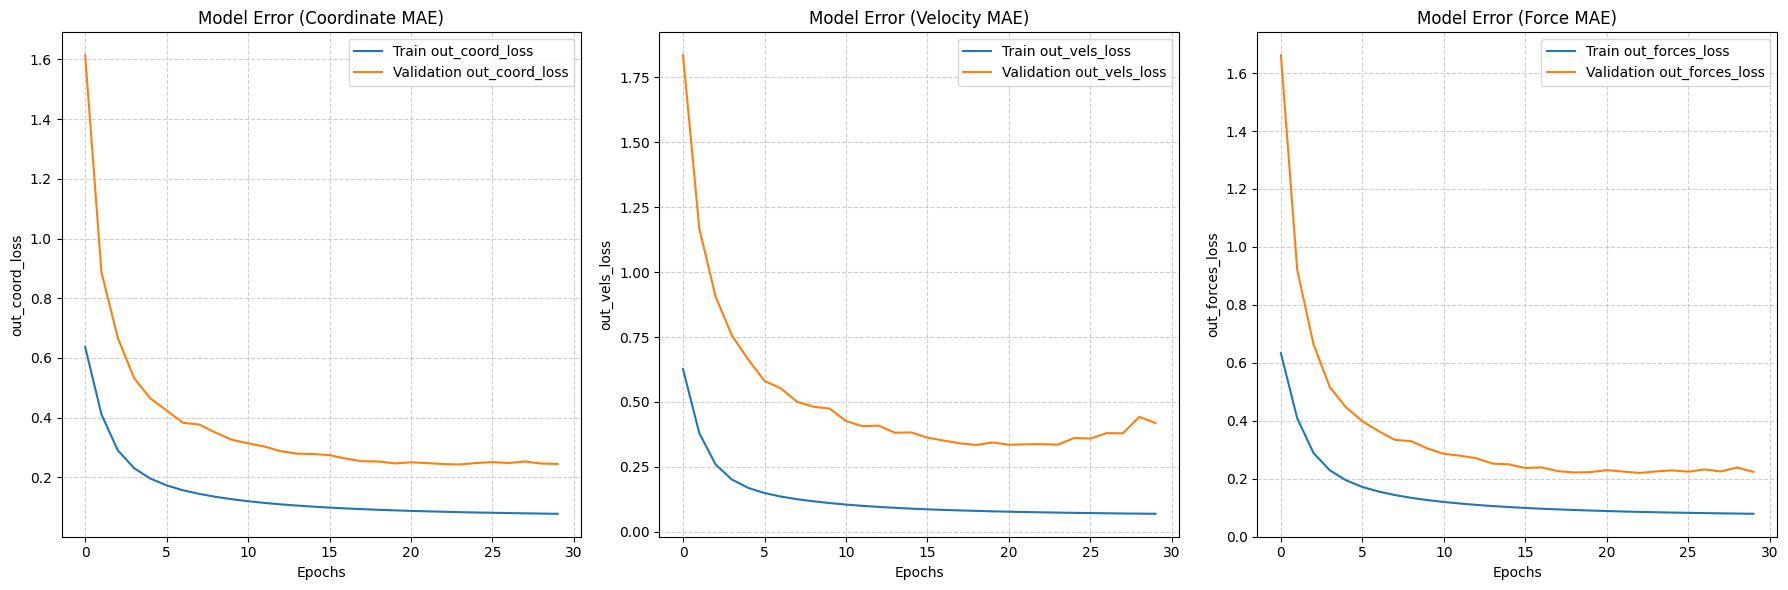

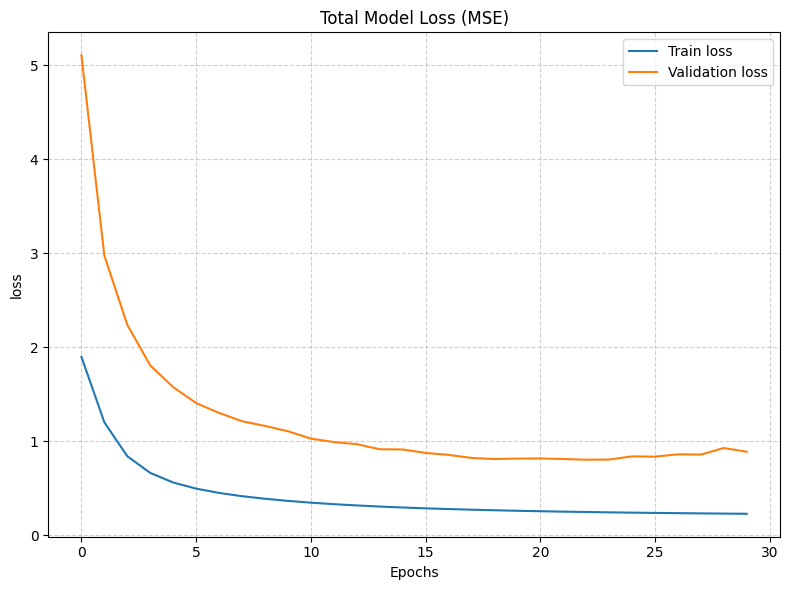

In [ ]:

def plot_graphs(history, metric, title):
    # Safely check if the metric exists in the history dictionary
    if metric in history.history:
        plt.plot(history.history[metric], label=f'Train {metric}')
        plt.plot(history.history['val_' + metric], label=f'Validation {metric}')
    else:
        print(f"Warning: Metric '{metric}' not found in history.")
        return # Exit if metric not found to avoid plotting empty data

    plt.xlabel("Epochs")
    plt.ylabel(metric)
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

plt.figure(figsize=(18, 6)) # Increased figure size to accommodate more subplots

# Subplot 1: Mean Absolute Error for Coordinates (dense_6_mean_absolute_error)
plt.subplot(1, 3, 1) # Changed to 1 row, 3 columns
# Based on model.summary() and model.fit() output, the MAE for coordinates (dense_6) is 'dense_6_mean_absolute_error'
plot_graphs(history, 'out_coord_loss', 'Model Error (Coordinate MAE)')

# Subplot 2: Mean Absolute Error for Velocities (dense_7_mean_absolute_error)
plt.subplot(1, 3, 2) # Changed to 1 row, 3 columns
# Based on model.summary() and model.fit() output, the MAE for velocities (dense_7) is 'dense_7_mean_absolute_error'
plot_graphs(history, 'out_vels_loss', 'Model Error (Velocity MAE)')

# Subplot 3: Mean Absolute Error for Forces (dense_8_mean_absolute_error)
plt.subplot(1, 3, 3) # Changed to 1 row, 3 columns
# Based on model.summary() and model.fit() output, the MAE for forces (dense_8) is 'dense_8_mean_absolute_error'
plot_graphs(history, 'out_forces_loss', 'Model Error (Force MAE)')

plt.tight_layout()
plt.savefig('training_curves_mae.png') # Saved with a new name to reflect the content
plt.show()

plt.figure(figsize=(8, 6))
# Separate plot for Total Loss (Mean Squared Error)
plot_graphs(history, 'loss', 'Total Model Loss (MSE)')
plt.tight_layout()
plt.savefig('training_curves_loss.png')
plt.show()

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


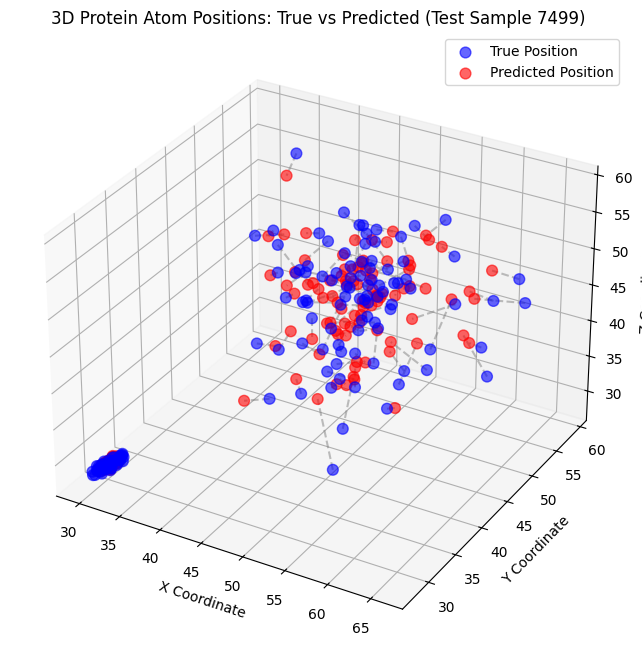

In [ ]:
# 1. Predict all three outputs
predictions = model.predict([testX_coord, testX_vels, testX_forces])

# 2. Extract ONLY the coordinate predictions (assuming it is the first output)
# predictions[0] = coords, predictions[1] = vels, predictions[2] = forces
pred_coords_scaled = predictions[0]

# 3. Create and fit a new scaler specifically for coordinates
# The original 'coords' array holds unscaled coordinate data
coord_scaler = StandardScaler()
# Fit on the training part of the original coordinate data, reshaped to 2D
coord_scaler.fit(coords[:train_end].reshape(train_end, -1))

# 4. Inverse transform using the new coordinate scaler
pred_coords_real = coord_scaler.inverse_transform(pred_coords_scaled)
testY_coord_real = coord_scaler.inverse_transform(testY_coord)

# 5. Reshape for 3D plotting
# NUM_ATOMS is already defined, feaature_xyz is 3
preds_reshaped = pred_coords_real.reshape(-1, NUM_ATOMS, feaature_xyz)
true_reshaped = testY_coord_real.reshape(-1, NUM_ATOMS, feaature_xyz)

# 6. Pick a single prediction step to look at
sample_idx = 7500-1

# 7. Slice out ONLY the first 3 columns (X, Y, Z) for all 138 atoms
# This step is redundant if feaature_xyz is already 3, but harmless.
preds_xyz = preds_reshaped[sample_idx, :, :]
true_xyz = true_reshaped[sample_idx, :, :]

# 8. Set up the 3D Matplotlib figure
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the True positions in Blue
ax.scatter(true_xyz[:, 0], true_xyz[:, 1], true_xyz[:, 2],
           c='blue', label='True Position', alpha=0.6, s=60)

# Plot the Predicted positions in Red
ax.scatter(preds_xyz[:, 0], preds_xyz[:, 1], preds_xyz[:, 2],
           c='red', label='Predicted Position', alpha=0.6, s=60)

# 9. Draw a line connecting the True atom to the Predicted atom to visualize the error
for i in range(NUM_ATOMS):
    ax.plot([true_xyz[i, 0], preds_xyz[i, 0]],
            [true_xyz[i, 1], preds_xyz[i, 1]],
            [true_xyz[i, 2], preds_xyz[i, 2]],
            color='gray', linestyle='--', alpha=0.5)

# Labels and Title
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Coordinate')
ax.set_title(f'3D Protein Atom Positions: True vs Predicted (Test Sample {sample_idx})')
plt.legend()
plt.show()

In [ ]:
import numpy as np
from google.colab import files

# Slice out ONLY the first 3 columns (X, Y, Z) for all timestamps and atoms
preds_xyz_all = pred_coords_real[:, :, 0:3]
true_xyz_all = true_coords_real[:, :, 0:3]

# Save the sliced arrays to a compressed file
filename = 'protein_dynamics_LSTM_Dense_Relation.npz'
np.savez_compressed(
    filename,
    preds=preds_xyz_all,
    true_vals=true_xyz_all
)

print(f"Data saved to {filename}. Downloading...")

# Trigger the download to your local machine
files.download(filename)

# Predict using a multiinput multinput model + Encoder


Insert the encoder of the transformer to evalute the relationship  between the input data intead to use simply dense layer

dff is the last dense layer number of parameter  inside the encoder

In [ ]:
look_back=4
epochs= 30
batchs_size=32

#Encoder Parameter
num_layers = 2
d_model = 128 #first dense layer parameter inside the PositionalEmbedding of the encoder
dff = 256
num_heads = 3 #multiattention branch
dropout_rate = 0.1

In [ ]:
nb_samples = len(features_scaled)

pad_rows = np.zeros((look_back, num_features))
features_padded = np.vstack((pad_rows, features_scaled))

X_reshaped = np.zeros((nb_samples, look_back, num_features))
Y_reshaped = np.zeros((nb_samples ,num_features))

for i in np.arange(0,nb_samples):
    X_reshaped[i] = features_padded[i:i+look_back].reshape(look_back, num_features)
    Y_reshaped[i] = features_scaled[i]

In [ ]:
trainX_coord=X_reshaped[:train_end,:,0:138*3]
testX_coord=X_reshaped[train_end:val_end,:,0:138*3]
valX_coord=X_reshaped[val_end:,:,0:138*3]

trainY_coord=Y_reshaped[:train_end,0:138*3]
testY_coord=Y_reshaped[train_end:val_end,0:138*3]
valY_coord=Y_reshaped[val_end:,0:138*3]

In [ ]:
trainX_vels=X_reshaped[:train_end,:,138*3:138*6]
testX_vels=X_reshaped[train_end:val_end,:,138*3:138*6]
valX_vels=X_reshaped[val_end:,:,138*3:138*6]

trainY_vels=Y_reshaped[:train_end,138*3:138*6]
testY_vels=Y_reshaped[train_end:val_end,138*3:138*6]
valY_vels=Y_reshaped[val_end:,138*3:138*6]

In [ ]:
trainX_forces=X_reshaped[:train_end,:,138*6:]
testX_forces=X_reshaped[train_end:val_end,:,138*6:]
valX_forces=X_reshaped[val_end:,:,138*6:]

trainY_forces=Y_reshaped[:train_end,138*6:]
testY_forces=Y_reshaped[train_end:val_end,138*6:]
valY_forces=Y_reshaped[val_end:,138*6:]

Encoder:

In [ ]:
def positional_encoding(length, depth):
    depth     = depth / 2
    positions = np.arange(length)[:, np.newaxis]
    depths    = np.arange(depth)[np.newaxis, :] / depth
    angle_rates  = 1 / (10000 ** depths)
    angle_rads   = positions * angle_rates
    pos_encoding = np.concatenate([np.sin(angle_rads), np.cos(angle_rads)], axis=-1)
    return tf.cast(pos_encoding, dtype=tf.float32)

class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, d_model, **kwargs):
        super().__init__(**kwargs)
        self.d_model      = d_model
        self.projection   = tf.keras.layers.Dense(d_model)
        self.pos_encoding = positional_encoding(length=2048, depth=d_model)
    def call(self, x):
        seq_len = tf.shape(x)[1]
        x  = self.projection(x)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x  = x + self.pos_encoding[tf.newaxis, :seq_len, :]
        return x

class BaseAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__()
        self.mha       = tf.keras.layers.MultiHeadAttention(**kwargs)
        self.layernorm = tf.keras.layers.LayerNormalization()
        self.add       = tf.keras.layers.Add()

class CrossAttention(BaseAttention):
    def call(self, x, context):
        attn_output, attn_scores = self.mha(
            query=x, key=context, value=context, return_attention_scores=True)
        self.last_attn_scores = attn_scores
        x = self.add([x, attn_output])
        x = self.layernorm(x)
        return x

class GlobalSelfAttention(BaseAttention):
    def call(self, x):
        attn_output = self.mha(query=x, value=x, key=x)
        x = self.add([x, attn_output])
        x = self.layernorm(x)
        return x

class CausalSelfAttention(BaseAttention):
    def call(self, x):
        attn_output = self.mha(query=x, value=x, key=x, use_causal_mask=True)
        x = self.add([x, attn_output])
        x = self.layernorm(x)
        return x

class FeedForward(tf.keras.layers.Layer):
    def __init__(self, d_model, dff, dropout_rate=0.1):
        super().__init__()
        self.seq = tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation='relu'),
            tf.keras.layers.Dense(d_model),
            tf.keras.layers.Dropout(dropout_rate)])
        self.add        = tf.keras.layers.Add()
        self.layer_norm = tf.keras.layers.LayerNormalization()
    def call(self, x):
        x = self.add([x, self.seq(x)])
        x = self.layer_norm(x)
        return x

class EncoderLayer(tf.keras.layers.Layer):
    def __init__(self, *, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        self.self_attention = GlobalSelfAttention(
            num_heads=num_heads, key_dim=d_model, dropout=dropout_rate)
        self.ffn = FeedForward(d_model, dff)
    def call(self, x):
        x = self.self_attention(x)
        x = self.ffn(x)
        return x

class Encoder(tf.keras.layers.Layer):
    def __init__(self, *, num_layers, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        self.d_model       = d_model
        self.num_layers    = num_layers
        self.pos_embedding = PositionalEmbedding(d_model=d_model)
        self.enc_layers    = [EncoderLayer(d_model=d_model, num_heads=num_heads,
                              dff=dff, dropout_rate=dropout_rate) for _ in range(num_layers)]
        self.dropout = tf.keras.layers.Dropout(dropout_rate)
    def call(self, x):
        x = self.pos_embedding(x)
        x = self.dropout(x)
        for layer in self.enc_layers:
            x = layer(x)
        return x

In [ ]:
input_coord = tf.keras.layers.Input(shape=(look_back, 138*3), name='in_coord')
input_vels = tf.keras.layers.Input(shape=(look_back, 138*3), name='in_vels')
input_forces = tf.keras.layers.Input(shape=(look_back, 138*3), name='in_forces')

# 1. Non sovrascrivere input_vels, usa un nome nuovo
combined_all = tf.keras.layers.concatenate([input_coord, input_vels, input_forces])



relation = Encoder(num_layers=num_layers, d_model=d_model,
                               num_heads=num_heads, dff=dff, dropout_rate=dropout_rate)
relation = relation(combined_all)

# 2. Concatenazione dei rami specifici
relation_c = tf.keras.layers.concatenate([input_coord, relation])
relation_v = tf.keras.layers.concatenate([input_vels, relation])
relation_f = tf.keras.layers.concatenate([input_forces, relation])

cLSTM = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=False, dropout=0.1))(relation_c)
vLSTM = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=False, dropout=0.1))(relation_v)
fLSTM = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=False, dropout=0.1))(relation_f)

output_c = tf.keras.layers.Dense(NUM_ATOMS * feaature_xyz, name='out_coord')(cLSTM)
output_v = tf.keras.layers.Dense(NUM_ATOMS * feaature_xyz, name='out_vels')(vLSTM)
output_f = tf.keras.layers.Dense(NUM_ATOMS * feaature_xyz, name='out_forces')(fLSTM)

# 3. Ora gli 'inputs' puntano correttamente ai layer Input originali
model = tf.keras.Model(inputs=[input_coord, input_vels, input_forces], outputs=[output_c, output_v, output_f])

# Compile
model.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    metrics=[tf.keras.metrics.MeanAbsoluteError(), tf.keras.metrics.MeanAbsoluteError(), tf.keras.metrics.MeanAbsoluteError()] # Use MAE to track average error for each output
)

model.summary()

# Train
history = model.fit(
    x=[trainX_coord, trainX_vels, trainX_forces],
    y=[trainY_coord, trainY_vels, trainY_forces],
    epochs=epochs,
    batch_size=batchs_size,
    validation_data=([valX_coord, valX_vels, valX_forces], [valY_coord, valY_vels, valY_forces])
)

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ in_coord            │ (None, 4, 414)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_vels             │ (None, 4, 414)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_forces           │ (None, 4, 414)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 4, 1242)   │          0 │ in_coord[0][0],   │
│ (Concatenate)       │                   │            │ in_vels[0][0],    │
│                     │                   │            │ in_forces[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_1 (Encoder) │ (None, 4, 128)    │    687,744 │ concatenate_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 4, 542)    │          0 │ in_coord[0][0],   │
│ (Concatenate)       │                   │            │ encoder_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_10      │ (None, 4, 542)    │          0 │ in_vels[0][0],    │
│ (Concatenate)       │                   │            │ encoder_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_11      │ (None, 4, 542)    │          0 │ in_forces[0][0],  │
│ (Concatenate)       │                   │            │ encoder_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_7     │ (None, 256)       │    687,104 │ concatenate_9[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_8     │ (None, 256)       │    687,104 │ concatenate_10[0… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_9     │ (None, 256)       │    687,104 │ concatenate_11[0… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out_coord (Dense)   │ (None, 414)       │    106,398 │ bidirectional_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out_vels (Dense)    │ (None, 414)       │    106,398 │ bidirectional_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out_forces (Dense)  │ (None, 414)       │    106,398 │ bidirectional_9[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,068,250 (11.70 MB)

 Trainable params: 3,068,250 (11.70 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 49s 34ms/step - loss: 1.9291 - out_coord_loss: 0.6481 - out_coord_mean_absolute_error: 0.5715 - out_forces_loss: 0.6452 - out_forces_mean_absolute_error: 0.5704 - out_vels_loss: 0.6357 - out_vels_mean_absolute_error: 0.5716 - val_loss: 5.4421 - val_out_coord_loss: 1.7253 - val_out_coord_mean_absolute_error: 1.0958 - val_out_forces_loss: 1.7476 - val_out_forces_mean_absolute_error: 1.0919 - val_out_vels_loss: 1.9761 - val_out_vels_mean_absolute_error: 1.1501
Epoch 2/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 34s 31ms/step - loss: 1.2211 - out_coord_loss: 0.4219 - out_coord_mean_absolute_error: 0.4665 - out_forces_loss: 0.4189 - out_forces_mean_absolute_error: 0.4652 - out_vels_loss: 0.3803 - out_vels_mean_absolute_error: 0.4467 - val_loss: 3.1217 - val_out_coord_loss: 0.9475 - val_out_coord_mean_absolute_error: 0.8038 - val_out_forces_loss: 0.9693 - val_out_forces_mean_absolute_error: 0.8131 - val_out_vels_loss: 1.2082 - val_out_vels_mean_absolute_error:

Save the model or load it from the drive

In [ ]:
driver_path='/content/drive/MyDrive/ProteinDynamics/'

In [ ]:
model.save(driver_path+'model_EncoderRelation.keras')

In [ ]:
model = keras.models.load_model(driver_path+'model_EncoderRelation.keras')


In [ ]:
trainPredict = model.predict([testX_coord,testX_vels,testX_forces])
# make predictions

235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


In [ ]:
results = model.evaluate([testX_coord,testX_vels,testX_forces],[testY_coord,testY_vels,testY_forces])

total_loss = results[0]
coord_loss = results[1]
coord_mae = results[2]
vels_loss = results[3]
vels_mae = results[4]
forces_loss = results[5]
forces_mae = results[6]

print('Test Total Loss:', total_loss)
print('Test MAE for Coordinates:', coord_mae)
print('Test MAE for Velocities:', vels_mae)
print('Test MAE for Forces:', forces_mae)

235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.4492 - out_coord_loss: 0.1403 - out_coord_mean_absolute_error: 0.2639 - out_forces_loss: 0.1418 - out_forces_mean_absolute_error: 0.2621 - out_vels_loss: 0.1675 - out_vels_mean_absolute_error: 0.2740
Test Total Loss: 0.44915667176246643
Test MAE for Coordinates: 0.16750174760818481
Test MAE for Velocities: 0.2639455497264862
Test MAE for Forces: 0.2739523649215698


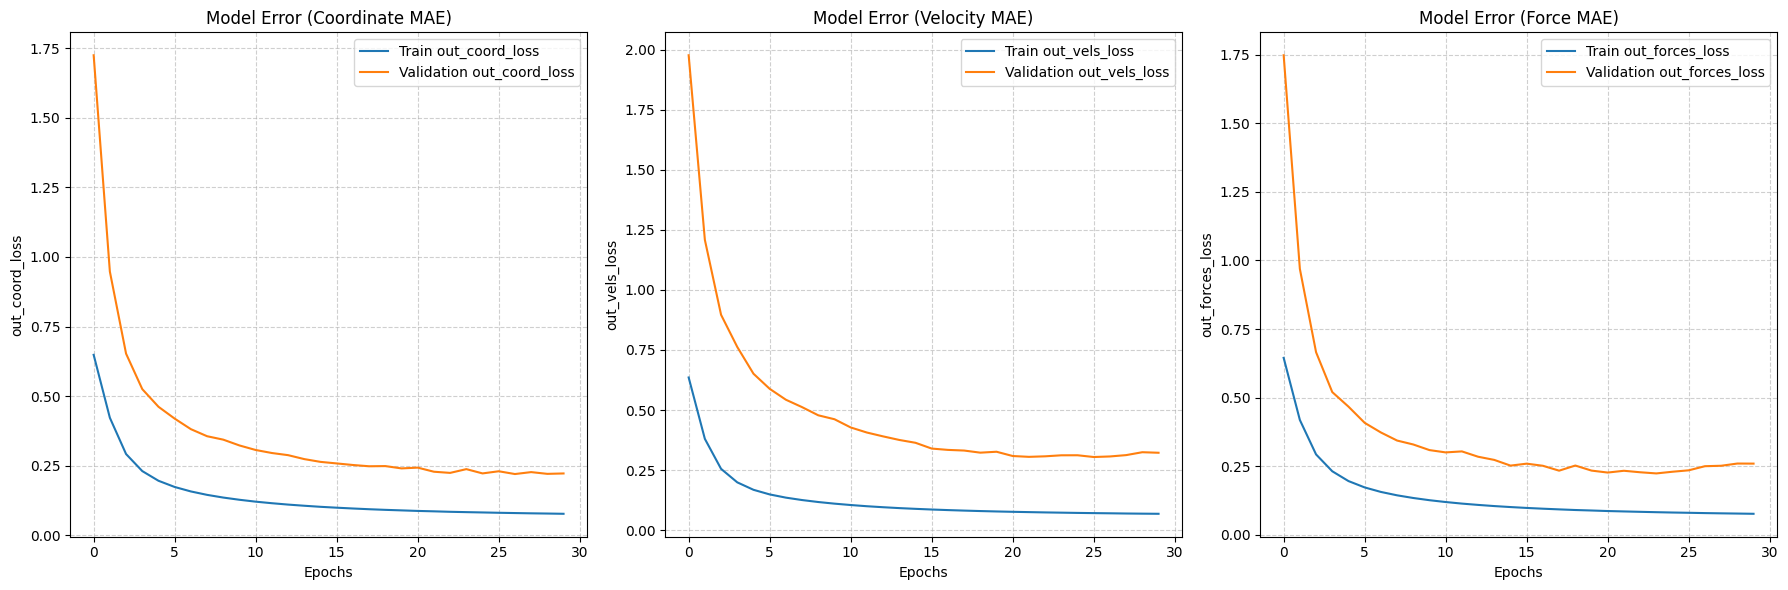

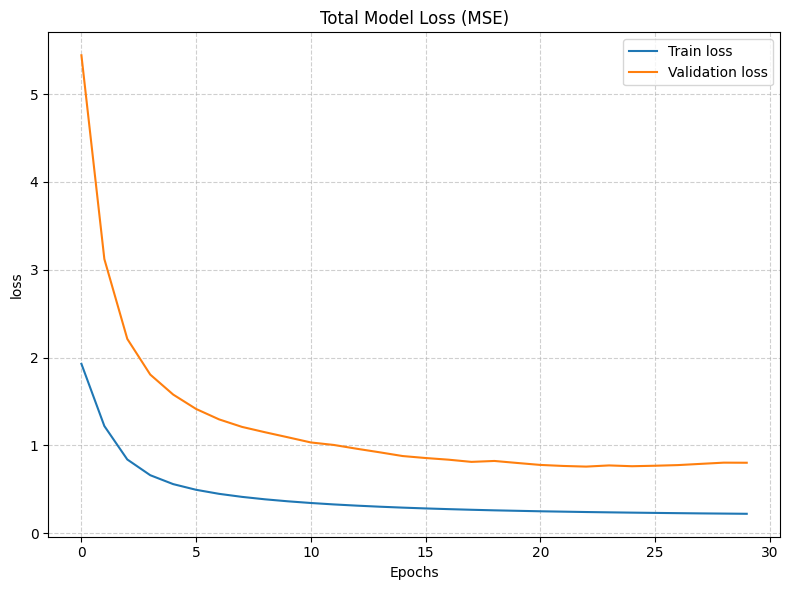

In [ ]:

def plot_graphs(history, metric, title):
    # Safely check if the metric exists in the history dictionary
    if metric in history.history:
        plt.plot(history.history[metric], label=f'Train {metric}')
        plt.plot(history.history['val_' + metric], label=f'Validation {metric}')
    else:
        print(f"Warning: Metric '{metric}' not found in history.")
        return # Exit if metric not found to avoid plotting empty data

    plt.xlabel("Epochs")
    plt.ylabel(metric)
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

plt.figure(figsize=(18, 6)) # Increased figure size to accommodate more subplots

# Subplot 1: Mean Absolute Error for Coordinates (dense_6_mean_absolute_error)
plt.subplot(1, 3, 1) # Changed to 1 row, 3 columns
# Based on model.summary() and model.fit() output, the MAE for coordinates (dense_6) is 'dense_6_mean_absolute_error'
plot_graphs(history, 'out_coord_loss', 'Model Error (Coordinate MAE)')

# Subplot 2: Mean Absolute Error for Velocities (dense_7_mean_absolute_error)
plt.subplot(1, 3, 2) # Changed to 1 row, 3 columns
# Based on model.summary() and model.fit() output, the MAE for velocities (dense_7) is 'dense_7_mean_absolute_error'
plot_graphs(history, 'out_vels_loss', 'Model Error (Velocity MAE)')

# Subplot 3: Mean Absolute Error for Forces (dense_8_mean_absolute_error)
plt.subplot(1, 3, 3) # Changed to 1 row, 3 columns
# Based on model.summary() and model.fit() output, the MAE for forces (dense_8) is 'dense_8_mean_absolute_error'
plot_graphs(history, 'out_forces_loss', 'Model Error (Force MAE)')

plt.tight_layout()
plt.savefig('training_curves_mae.png') # Saved with a new name to reflect the content
plt.show()

plt.figure(figsize=(8, 6))
# Separate plot for Total Loss (Mean Squared Error)
plot_graphs(history, 'loss', 'Total Model Loss (MSE)')
plt.tight_layout()
plt.savefig('training_curves_loss.png')
plt.show()

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


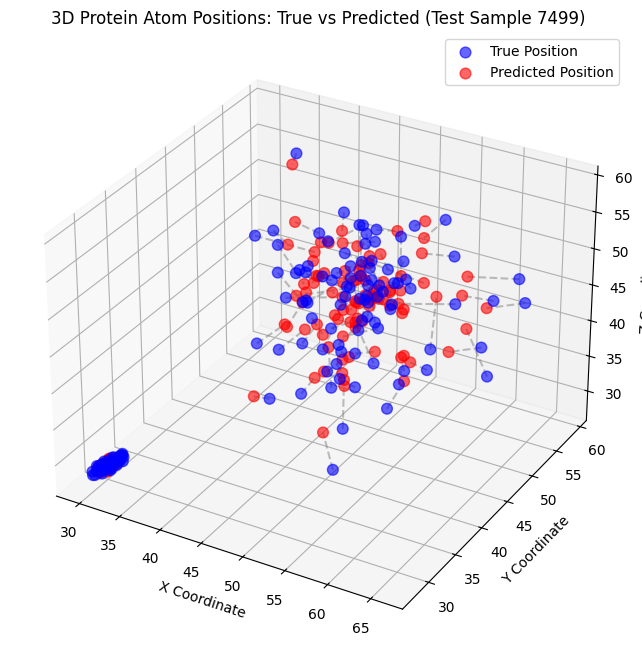

In [ ]:
# 1. Predict all three outputs
predictions = model.predict([testX_coord, testX_vels, testX_forces])

# 2. Extract ONLY the coordinate predictions (assuming it is the first output)
# predictions[0] = coords, predictions[1] = vels, predictions[2] = forces
pred_coords_scaled = predictions[0]

# 3. Create and fit a new scaler specifically for coordinates
# The original 'coords' array holds unscaled coordinate data
coord_scaler = StandardScaler()
# Fit on the training part of the original coordinate data, reshaped to 2D
coord_scaler.fit(coords[:train_end].reshape(train_end, -1))

# 4. Inverse transform using the new coordinate scaler
pred_coords_real = coord_scaler.inverse_transform(pred_coords_scaled)
testY_coord_real = coord_scaler.inverse_transform(testY_coord)

# 5. Reshape for 3D plotting
# NUM_ATOMS is already defined, feaature_xyz is 3
preds_reshaped = pred_coords_real.reshape(-1, NUM_ATOMS, feaature_xyz)
true_reshaped = testY_coord_real.reshape(-1, NUM_ATOMS, feaature_xyz)

# 6. Pick a single prediction step to look at
sample_idx = 7500-1

# 7. Slice out ONLY the first 3 columns (X, Y, Z) for all 138 atoms
# This step is redundant if feaature_xyz is already 3, but harmless.
preds_xyz = preds_reshaped[sample_idx, :, :]
true_xyz = true_reshaped[sample_idx, :, :]

# 8. Set up the 3D Matplotlib figure
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the True positions in Blue
ax.scatter(true_xyz[:, 0], true_xyz[:, 1], true_xyz[:, 2],
           c='blue', label='True Position', alpha=0.6, s=60)

# Plot the Predicted positions in Red
ax.scatter(preds_xyz[:, 0], preds_xyz[:, 1], preds_xyz[:, 2],
           c='red', label='Predicted Position', alpha=0.6, s=60)

# 9. Draw a line connecting the True atom to the Predicted atom to visualize the error
for i in range(NUM_ATOMS):
    ax.plot([true_xyz[i, 0], preds_xyz[i, 0]],
            [true_xyz[i, 1], preds_xyz[i, 1]],
            [true_xyz[i, 2], preds_xyz[i, 2]],
            color='gray', linestyle='--', alpha=0.5)

# Labels and Title
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Coordinate')
ax.set_title(f'3D Protein Atom Positions: True vs Predicted (Test Sample {sample_idx})')
plt.legend()
plt.show()

In [ ]:
import numpy as np
from google.colab import files

# Slice out ONLY the first 3 columns (X, Y, Z) for all timestamps and atoms
preds_xyz_all = pred_coords_real[:, :, 0:3]
true_xyz_all = true_coords_real[:, :, 0:3]

# Save the sliced arrays to a compressed file
filename = 'protein_dynamics_LSTM_Encoder_Relation.npz'
np.savez_compressed(
    filename,
    preds=preds_xyz_all,
    true_vals=true_xyz_all
)

print(f"Data saved to {filename}. Downloading...")

# Trigger the download to your local machine
files.download(filename)